# بخش دوم سوال دوم

In [25]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import copy
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

## زیربخش اول

In [26]:
class SCM:
    def __init__(self) -> None:
        self.variables = {}

    def add_variable(self, name, parents, equation) -> None:
        self.variables[name] = {
            "parents": parents,
            "equation": equation
        }

    def sample(self, n_samples) -> pd.DataFrame:
        data = {}
        computed_vars = set()

        while len(computed_vars) < len(self.variables):
            for var, info in self.variables.items():
                if var not in computed_vars:
                    parents_ready = True
                    for parent in info["parents"]:
                        if parent not in computed_vars:
                            parents_ready = False
                            break
                    
                    if parents_ready:
                        data[var] = info["equation"](n_samples, data)
                        computed_vars.add(var)
                        
        return pd.DataFrame(data)

    def do_operator(self, interventions) -> "SCM":
            new_scm = copy.deepcopy(self)
            
            for var, value in interventions.items():
                if var in new_scm.variables:
                    new_scm.variables[var]["parents"] = []
                    
                    def constant_equation(n_samples, _, value=value):
                        return np.full(n_samples, value)
                    
                    new_scm.variables[var]["equation"] = constant_equation
                    
            return new_scm

    def plot_graph(self, title) -> None:
        G = nx.DiGraph()
        
        for var, info in self.variables.items():
            G.add_node(var)
            for par in info["parents"]:
                G.add_edge(par, var)
                
        plt.figure(figsize=(6, 4))
        pos = nx.spring_layout(G, seed=42) 
        nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=2000, arrows=True)
        plt.title(title)
        plt.show()

## زیربخش دوم

### الف

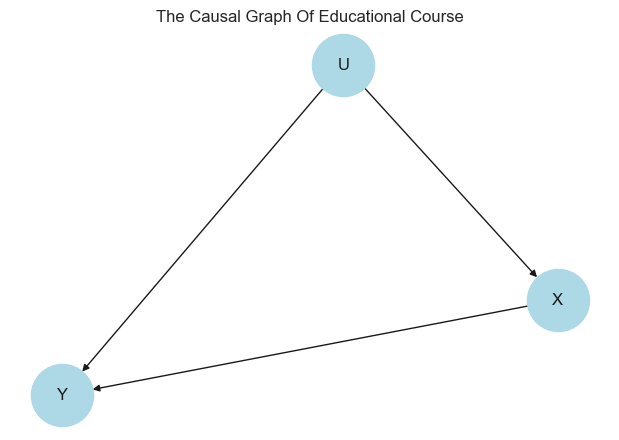

In [27]:
model = SCM()

model.add_variable("U", [], lambda num,data: np.random.normal(0, 1, num))

model.add_variable("X", ["U"], lambda num,data: (7 * data["U"] + np.random.normal(0, 1, num) > 0).astype(int))

model.add_variable("Y", ["X", "U"], lambda num,data: 3 * data["X"] + 2 * data["U"] + np.random.normal(0, 1, num))

model.plot_graph(title = "The Causal Graph Of Educational Course")

### ب

In [28]:
obs_data = model.sample(n_samples = 10000)

E1 = obs_data[obs_data['X'] == 1]['Y'].mean()
E0 = obs_data[obs_data['X'] == 0]['Y'].mean()

print(f"E[Y|X=1]: {E1:.4f}")
print(f"E[Y|X=0]: {E0:.4f}")
print(f"Observational Difference: {E1 - E0:.4f}")

E[Y|X=1]: 4.6148
E[Y|X=0]: -1.6392
Observational Difference: 6.2541


### ج

In [29]:
model_do1 = model.do_operator({'X': 1})
do1_data = model_do1.sample(n_samples = 10000)
E_do1 = do1_data['Y'].mean()

model_do0 = model.do_operator({'X': 0})
do0_data = model_do0.sample(n_samples = 10000)
E_do0 = do0_data['Y'].mean()

print(f"E[Y|do(X=1)]: {E_do1:.4f}")
print(f"E[Y|do(X=0)]: {E_do0:.4f}")
print(f"True Causal Effect (ATE): {E_do1 - E_do0:.4f}")

E[Y|do(X=1)]: 3.0027
E[Y|do(X=0)]: 0.0166
True Causal Effect (ATE): 2.9861


## زیربخش سوم

### ساخت مدل و نمایش گراف علّی

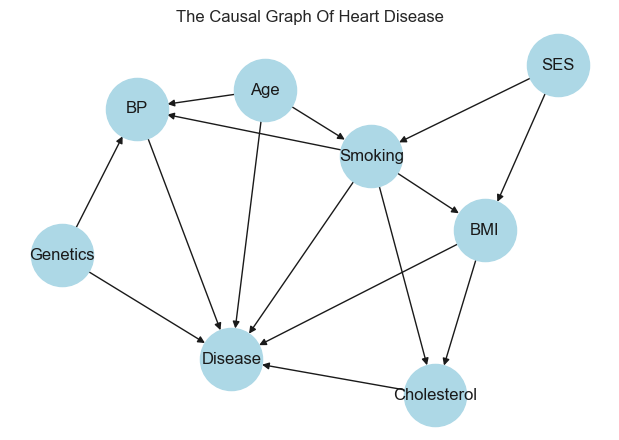

In [30]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

model2 = SCM()

model2.add_variable('Age', [], lambda num, data: np.random.normal(50, 10, num))
model2.add_variable('SES', [], lambda num, data: np.random.normal(0, 1, num))
model2.add_variable('Genetics', [], lambda num, data: np.random.normal(0, 1, num))

model2.add_variable('Smoking', ['Age', 'SES'], 
                   lambda num, data: (np.random.uniform(0, 1, num) < sigmoid(-2 + 0.03 * data['Age'] - 0.5 * data['SES'])).astype(int))

model2.add_variable('BMI', ['Smoking', 'SES'], 
                   lambda num, data: 25 + 2 * data['Smoking'] - data['SES'] + np.random.normal(0, 3, num))

model2.add_variable('BP', ['Smoking', 'Age', 'Genetics'], 
                   lambda num, data: 120 + 5 * data['Smoking'] + 0.3 * data['Age'] + 2 * data['Genetics'] + np.random.normal(0, 10, num))

model2.add_variable('Cholesterol', ['Smoking', 'BMI'], 
                   lambda num, data: 180 + 10 * data['Smoking'] - 0.5 * data['BMI'] + np.random.normal(0, 15, num))

model2.add_variable('Disease', ['Smoking', 'Age', 'BMI', 'BP', 'Cholesterol', 'Genetics'], 
                   lambda num, data: sigmoid(-15 + 0.6 * data['Smoking'] + 0.02 * data['Age'] + 0.01 * data['BMI'] + 0.03 * data['BP'] + 0.04 * data['Cholesterol'] + 0.2 * data['Genetics']))

model2.plot_graph(title="The Causal Graph Of Heart Disease")

### ATE

In [31]:
model_do_smoke = model2.do_operator({'Smoking': 1})
data_do_smoke = model_do_smoke.sample(n_samples = 10000)
E_Disease_do1 = data_do_smoke['Disease'].mean()

model_do_noSmoke = model2.do_operator({'Smoking': 0})
data_do_noSmoke = model_do_noSmoke.sample(n_samples = 10000)
E_Disease_do0 = data_do_noSmoke['Disease'].mean()

ATE = E_Disease_do1 - E_Disease_do0

print(f"E[Disease | do(Smoking=1)]: {E_Disease_do1:.4f}")
print(f"E[Disease | do(Smoking=0)]: {E_Disease_do0:.4f}")
print(f"ATE: {ATE:.4f}")

E[Disease | do(Smoking=1)]: 0.1570
E[Disease | do(Smoking=0)]: 0.0611
ATE: 0.0960


### ATT

In [32]:
obs_data2 = model2.sample(n_samples = 10000)

smokers = obs_data2[obs_data2['Smoking'] == 1].copy()
E_do1_givenS1 = smokers['Disease'].mean()

new_smokers = smokers.copy()
new_smokers['Smoking'] = 0

new_smokers['BMI'] = 25 + 2 * new_smokers['Smoking'] - new_smokers['SES'] + np.random.normal(0, 3, len(new_smokers))
new_smokers['BP'] = 120 + 5 * new_smokers['Smoking'] + 0.3 * new_smokers['Age'] + 2 * new_smokers['Genetics'] + np.random.normal(0, 10, len(new_smokers))
new_smokers['Cholesterol'] = 180 + 10 * new_smokers['Smoking'] - 0.5 * new_smokers['BMI'] + np.random.normal(0, 15, len(new_smokers))
new_smokers['Disease'] = sigmoid(-15 + 0.6 * new_smokers['Smoking'] + 0.02 * new_smokers['Age'] + 0.01 * new_smokers['BMI'] + 0.03 * new_smokers['BP'] + 0.04 * new_smokers['Cholesterol'] + 0.2 * new_smokers['Genetics'])

E_do0_givenS1 = new_smokers['Disease'].mean()

ATT = E_do1_givenS1 - E_do0_givenS1

print(f"E[Disease | do(Smoking=1), Smoking=1]: {E_do1_givenS1:.4f}")
print(f"E[Disease | do(Smoking=0), Smoking=1]: {E_do0_givenS1:.4f}")
print(f"ATT: {ATT:.4f}")

E[Disease | do(Smoking=1), Smoking=1]: 0.1667
E[Disease | do(Smoking=0), Smoking=1]: 0.0640
ATT: 0.1028


### CATE

In [33]:
E_old_do1 = data_do_smoke[data_do_smoke['Age'] > 55]['Disease'].mean()
E_old_do0 = data_do_noSmoke[data_do_noSmoke['Age'] > 55]['Disease'].mean()
CATE_old = E_old_do1 - E_old_do0

print("Age Group: > 55:")
print(f"E[Disease | do(Smoking=1), Age > 55]: {E_old_do1:.4f}")
print(f"E[Disease | do(Smoking=0), Age > 55]: {E_old_do0:.4f}")
print(f"CATE (Age > 55): {CATE_old:.4f}\n")

E_young_do1 = data_do_smoke[data_do_smoke['Age'] <= 55]['Disease'].mean()
E_young_do0 = data_do_noSmoke[data_do_noSmoke['Age'] <= 55]['Disease'].mean()
CATE_young = E_young_do1 - E_young_do0

print("Age Group: <= 55:")
print(f"E[Disease | do(Smoking=1), Age <= 55]: {E_young_do1:.4f}")
print(f"E[Disease | do(Smoking=0), Age <= 55]: {E_young_do0:.4f}")
print(f"CATE (Age <= 55): {CATE_young:.4f}")

Age Group: > 55:
E[Disease | do(Smoking=1), Age > 55]: 0.1984
E[Disease | do(Smoking=0), Age > 55]: 0.0796
CATE (Age > 55): 0.1188

Age Group: <= 55:
E[Disease | do(Smoking=1), Age <= 55]: 0.1379
E[Disease | do(Smoking=0), Age <= 55]: 0.0527
CATE (Age <= 55): 0.0852


## زیربحش چهارم

### بخش یک: حالت ساده‌لوحانه

In [34]:
df = pd.read_csv('website_engagement_data.csv')

mean = df.groupby('layout')['time_spent'].mean()
print("Average time spent for each layout:")
print(mean)
print("-" * 30)

site_model = smf.ols('time_spent ~ C(layout)', data=df).fit()

print(site_model.summary())

Average time spent for each layout:
layout
New_Layout     9.730547
Old_Layout    12.501732
Name: time_spent, dtype: float64
------------------------------
                            OLS Regression Results                            
Dep. Variable:             time_spent   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     101.7
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           7.64e-23
Time:                        11:44:30   Log-Likelihood:                -2877.8
No. Observations:                1000   AIC:                             5760.
Df Residuals:                     998   BIC:                             5769.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          

### بخش دو: تشخیص بصری

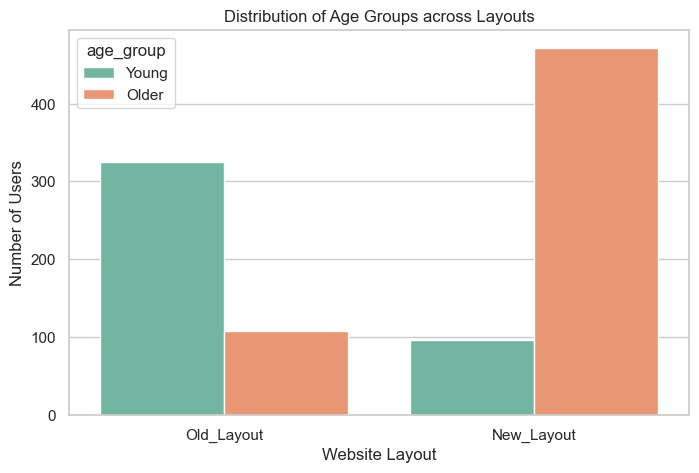

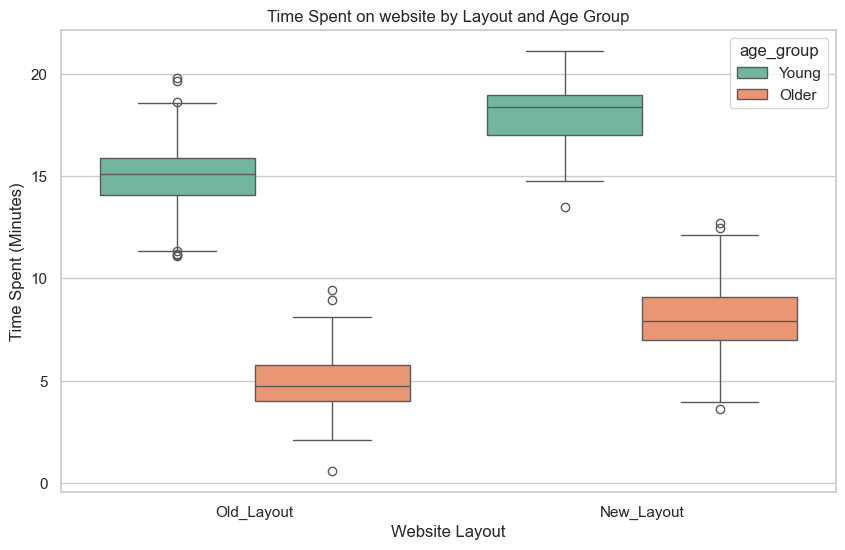

In [35]:
# نمودار اول: تحلیل توزیع
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='layout', hue='age_group', palette='Set2')
plt.title('Distribution of Age Groups across Layouts')
plt.xlabel('Website Layout')
plt.ylabel('Number of Users')
plt.show()

# نمودار دوم: بصری‌سازی تناقض
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='layout', y='time_spent', hue='age_group', palette='Set2')
plt.title('Time Spent on website by Layout and Age Group')
plt.xlabel('Website Layout')
plt.ylabel('Time Spent (Minutes)')
plt.show()

### بخش سه: حل مسئله علّی

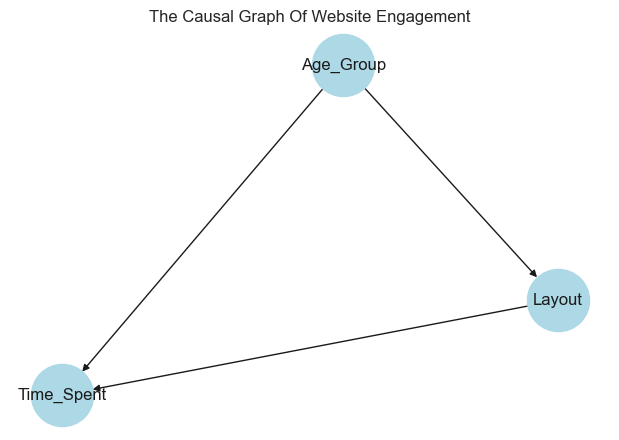


Controlled Regression Results:
                            OLS Regression Results                            
Dep. Variable:             time_spent   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     4231.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:44:42   Log-Likelihood:                -1801.4
No. Observations:                1000   AIC:                             3609.
Df Residuals:                     997   BIC:                             3624.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [36]:
# رسم گراف علی
model_website = SCM()
model_website.add_variable('Age_Group', [], lambda num, data: None) 
model_website.add_variable('Layout', ['Age_Group'], lambda num, data: None) 
model_website.add_variable('Time_Spent', ['Layout', 'Age_Group'], lambda num, data: None)
model_website.plot_graph(title="The Causal Graph Of Website Engagement")

# رگرسیون کنترل شده
site_model2 = smf.ols('time_spent ~ C(layout) + C(age_group)', data=df).fit()
print("\nControlled Regression Results:")
print(site_model2.summary())

### بخش چهار: اثبات پایداری و صحت مدل

In [37]:
df['shuffled_layout'] = np.random.permutation(df['layout'])

placebo_model = smf.ols('time_spent ~ C(shuffled_layout) + C(age_group)', data=df).fit()

print("\nPlacebo Test Regression Results:")
print(placebo_model.summary())


Placebo Test Regression Results:
                            OLS Regression Results                            
Dep. Variable:             time_spent   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     2255.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:44:49   Log-Likelihood:                -2071.9
No. Observations:                1000   AIC:                             4150.
Df Residuals:                     997   BIC:                             4164.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------